<a href="https://colab.research.google.com/github/dinujakr/Final-year-project-IEKF-for-rigid-body-tracking/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Simulation and experimental verification of a Intrinsic Extended Kalman filter for rigid body attitude tracking

#Linear Kalman Filter

Testing the linear kalman filter under smooth and rapid rotations using EuroC Datasets

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Load Data sets

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ============================================================
# CHANGE THIS to switch between EuRoC MAV sequences
# Easy:   r"F:\Uni\FYP\ES7 3 exam\MH_01_easy"
# Medium: r"F:\Uni\FYP\ES7 3 example\MH_03_medium"
# Hard:   r"F:\Uni\FYP\ES7 3 example\MH_05_difficult"
# Very hard: r"F:\Uni\FYP\ES7 3 example\V2_03_difficult"

DATASET = "/content/drive/MyDrive/FYP/V2_03_difficult"
# ============================================================

imu_path = DATASET + r"/imu0/data.csv"
gt_path  = DATASET + r"/state_groundtruth_estimate0/data.csv"

# Load CSV
imu = pd.read_csv(imu_path)
gt  = pd.read_csv(gt_path)

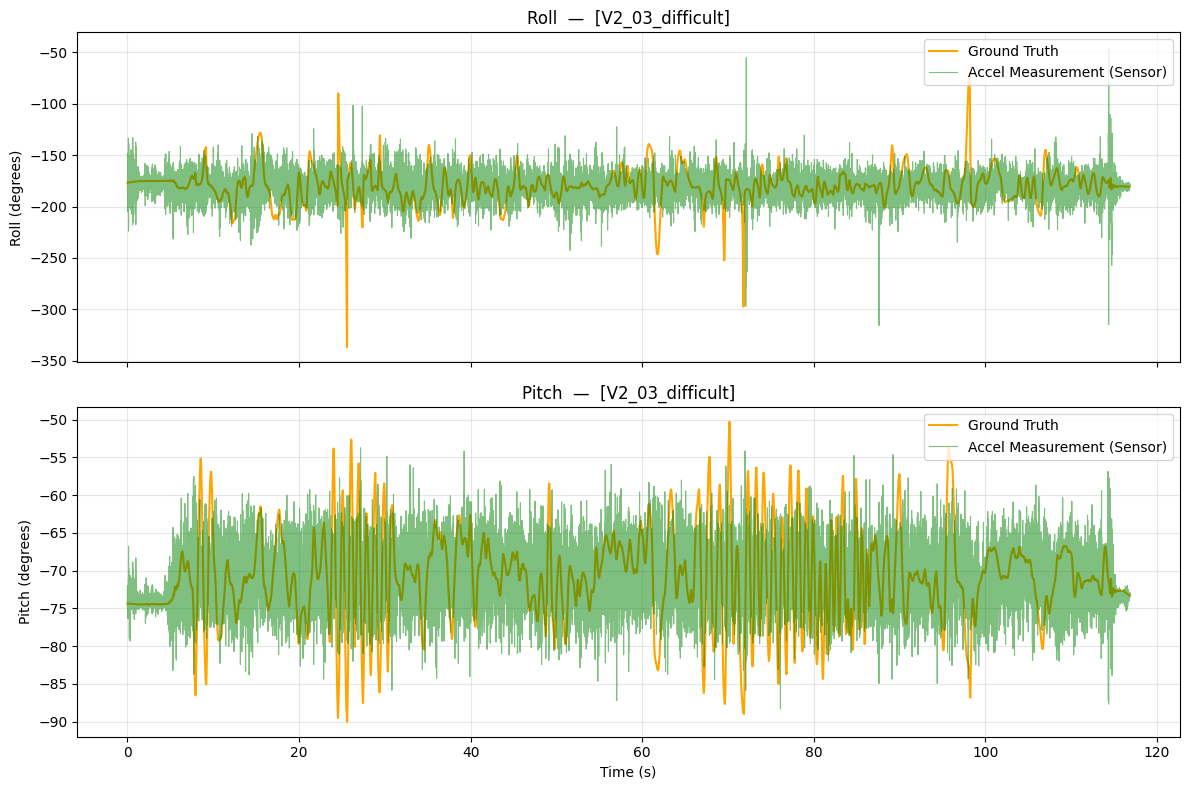

In [4]:
t0 = min(imu.iloc[0,0], gt.iloc[0,0])   # same global reference

# IMU Timeline and raw values
t_imu = (imu.iloc[:,0].values - t0) * 1e-9
gyro = imu.iloc[:,1:4].values   # wx, wy, wz
acc  = imu.iloc[:,4:7].values   # ax, ay, az

# GT Timeline
t_gt  = (gt.iloc[:,0].values  - t0) * 1e-9

# Quaternion
q_gt = gt[[' q_RS_w []',' q_RS_x []',' q_RS_y []',' q_RS_z []']].values


# --- CONVERSION & UTILITY FUNCTIONS ---

# Convert accelerometer to Euler angles
def accel_to_euler(acc):
    ax, ay, az = acc
    norm = np.linalg.norm(acc)
    if norm == 0:
        return np.array([0.0, 0.0])
    ax, ay, az = ax/norm, ay/norm, az/norm

    phi = np.arctan2(ay, az)
    theta = np.arctan2(-ax, np.sqrt(ay**2 + az**2))

    return np.array([phi, theta])

# Convert Ground Truth Quaternions to Euler angles
def quat_to_euler(q):
    w, x, y, z = q
    phi = np.arctan2(2 * (w*x + y*z), 1 - 2 * (x*x + y*y))
    sin_pitch = np.clip(2 * (w*y - z*x), -1.0, 1.0)
    theta = np.arcsin(sin_pitch)
    psi = np.arctan2(2 * (w*z + x*y), 1 - 2 * (y*y + z*z))
    return np.array([phi, theta, psi])

# Properly unwrap cumulative angle trajectories to remove ±π wrap jumps
def unwrap_angle(a):
    a_unwrapped = np.copy(a)
    for i in range(1, len(a_unwrapped)):
        diff = a_unwrapped[i] - a_unwrapped[i-1]
        while diff > np.pi:
            a_unwrapped[i] -= 2 * np.pi
            diff -= 2 * np.pi
        while diff < -np.pi:
            a_unwrapped[i] += 2 * np.pi
            diff += 2 * np.pi
    return a_unwrapped


# --- DATA PROCESSING ---

# 1. Compute and unwrap direct sensor orientations from entire Accelerometer log
roll_meas = np.arctan2(acc[:, 1], acc[:, 2])
pitch_meas = np.arctan2(-acc[:, 0], np.sqrt(acc[:, 1]**2 + acc[:, 2]**2))

roll_meas = unwrap_angle(roll_meas)
pitch_meas = unwrap_angle(pitch_meas)

# 2. Extract full Ground Truth Euler angles from quaternions and unwrap them
euler_gt = np.array([quat_to_euler(q) for q in q_gt])
euler_gt[:, 0] = unwrap_angle(euler_gt[:, 0])
euler_gt[:, 1] = unwrap_angle(euler_gt[:, 1])

# 3. Interpolate Ground Truth data perfectly over the IMU sensor timeline
interp_gt_roll  = interp1d(t_gt, euler_gt[:, 0], bounds_error=False, fill_value='extrapolate')
interp_gt_pitch = interp1d(t_gt, euler_gt[:, 1], bounds_error=False, fill_value='extrapolate')

gt_roll_unwrapped  = interp_gt_roll(t_imu)
gt_pitch_unwrapped = interp_gt_pitch(t_imu)

dataset_name = DATASET.split("/")[-1]


# --- PLOTTING DATA ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Roll subplot ---
ax1.plot(t_imu, np.degrees(gt_roll_unwrapped), label='Ground Truth', color='orange', linewidth=1.5)
ax1.plot(t_imu, np.degrees(roll_meas), label='Accel Measurement (Sensor)', color='green', alpha=0.5, linewidth=0.8)
ax1.set_ylabel("Roll (degrees)")
ax1.set_title(f"Roll  —  [{dataset_name}]")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Pitch subplot ---
ax2.plot(t_imu, np.degrees(gt_pitch_unwrapped), label='Ground Truth', color='orange', linewidth=1.5)
ax2.plot(t_imu, np.degrees(pitch_meas), label='Accel Measurement (Sensor)', color='green', alpha=0.5, linewidth=0.8)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Pitch (degrees)")
ax2.set_title(f"Pitch  —  [{dataset_name}]")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Linear system assumption and state estimation by linear kalman filter

$$
\mathbf{x} = \begin{bmatrix} \phi \\ \theta \\ \psi \end{bmatrix}
$$


Optimising Q & R  [1/10 sub-sample · Nelder-Mead · max 3000 iter]

Optimization terminated successfully.
         Current function value: 0.406599
         Iterations: 1415
         Function evaluations: 2788

  Optimised Q │ roll=1.582e-09  pitch=5.128e-35  b_wx=2.124e+17  b_wy=6.125e-19
  Optimised R │ roll=6.760e+17  pitch=3.782e-20

════════════════════════════════════════════════════════════════
                   RMSE Comparison  (degrees)                   
════════════════════════════════════════════════════════════════
  Method                         Roll       Pitch     Average
  ──────────────────────────────────────────────────────────────
  Gyro Prediction (pred)    307.8055°   133.2008°   220.5031°
  Accel Measurement (meas)    20.1030°     7.0477°    13.5753°
  KF Estimate                16.7388°     6.0221°    11.3805°  ◄ best
════════════════════════════════════════════════════════════════


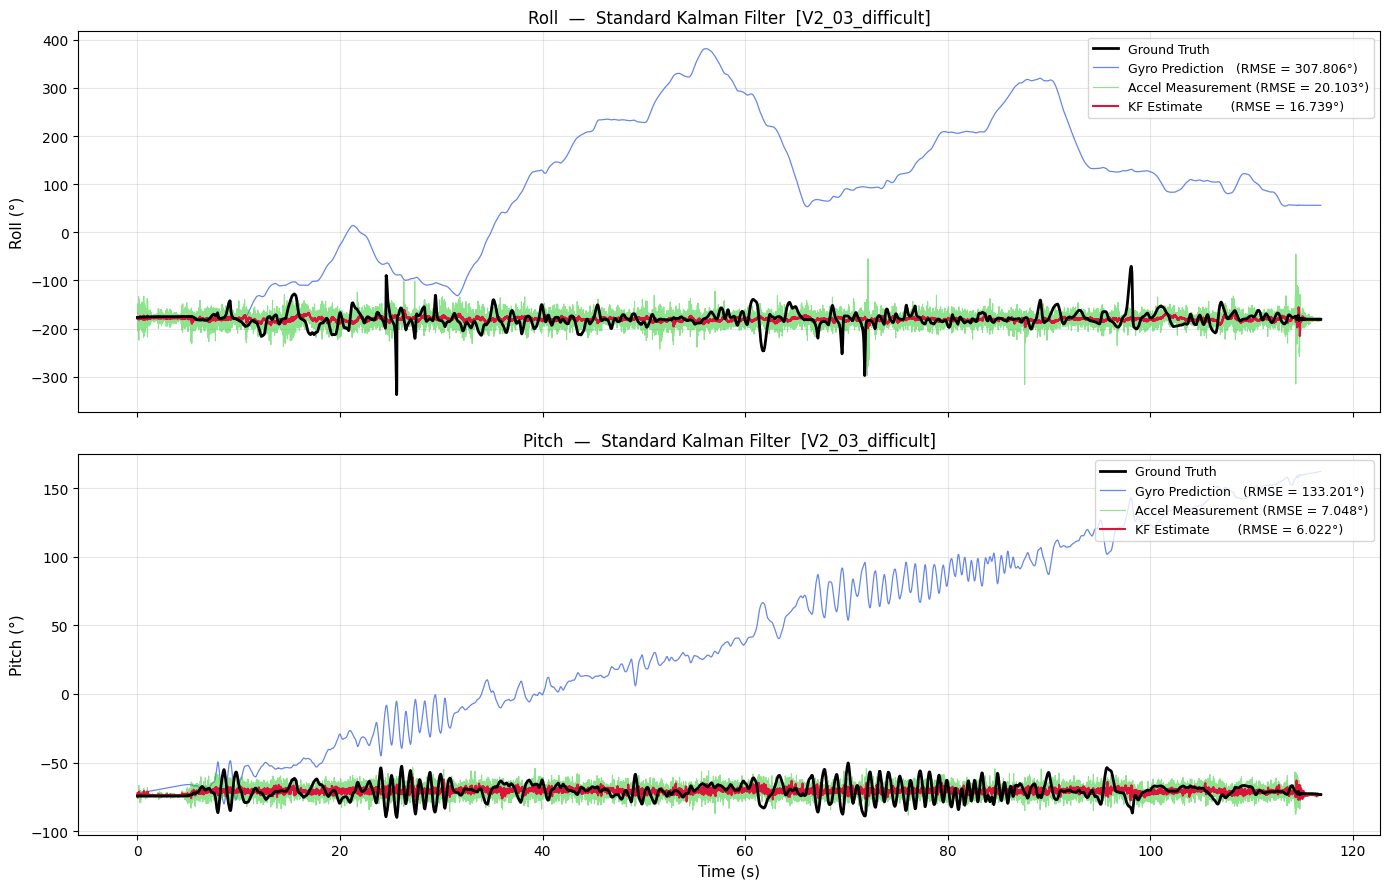

In [5]:
# ============================================================
#  STANDARD (LINEAR) KALMAN FILTER  —  Pitch & Roll Estimation
# ============================================================
#
#  State vector:  x = [roll, pitch, b_wx, b_wy]ᵀ          (4×1)
#
#  Process model  (linear, constant-structure matrices):
#
#       x_{k+1} = F_k x_k + B_k u_k + w_k,   w_k ~ N(0, Q)
#
#       F = ⎡1  0  -dt   0 ⎤    B = ⎡dt  0 ⎤    u = [wx]
#           ⎢0  1   0  -dt ⎥        ⎢ 0 dt ⎥        [wy]
#           ⎢0  0   1    0 ⎥        ⎢ 0  0 ⎥
#           ⎣0  0   0    1 ⎦        ⎣ 0  0 ⎦
#
#       Linear approx:  roll_rate  ≈ wx  (body-x gyro)
#                       pitch_rate ≈ wy  (body-y gyro)
#       (exact only at small angles — inherent linear-KF assumption)
#
#  Measurement model  (linear, constant H):
#
#       z_k = H x_k + v_k,   v_k ~ N(0, R)
#
#       H = [1 0 0 0]    z = [roll_accel ]   (accel-derived Euler)
#           [0 1 0 0]        [pitch_accel]
#
#  NOTE: Yaw is NOT estimated — accelerometer/gyro cannot correct
#        for yaw drift without a magnetometer reference.
#
#  Tuning: Nelder-Mead minimises RMSE(KF vs GT) over log(Q diag, R diag)
#          Search is done on a sub-sampled timeline for speed, then the
#          optimal parameters are re-applied to the full dataset.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ── Small helpers ────────────────────────────────────────────
def rmse(a, b): return np.sqrt(np.mean((a - b) ** 2))
def d(r):       return np.degrees(r)        # rad → degrees


# ─────────────────────────────────────────────────────────────
#  Standard linear Kalman Filter
# ─────────────────────────────────────────────────────────────
def run_standard_kf(t, gyro, roll_meas, pitch_meas, q_diag, r_diag):
    """
    Standard (linear) Kalman Filter for roll & pitch estimation.

    Parameters
    ----------
    t          : (N,) IMU timestamps [s]
    gyro       : (N,3) gyroscope  [rad/s]   — columns: wx, wy, wz
    roll_meas  : (N,) accelerometer roll  [rad]
    pitch_meas : (N,) accelerometer pitch [rad]
    q_diag     : (4,) diagonal of process-noise Q [roll, pitch, b_wx, b_wy]
    r_diag     : (2,) diagonal of meas-noise    R [roll, pitch]

    Returns
    -------
    kf_roll, kf_pitch : (N,) posterior angle estimates [rad]
    """
    N  = len(t)
    Q  = np.diag(q_diag)
    R  = np.diag(r_diag)
    H  = np.array([[1, 0, 0, 0],
                   [0, 1, 0, 0]], dtype=float)   # observes roll & pitch
    I4 = np.eye(4)

    kf_roll  = np.empty(N)
    kf_pitch = np.empty(N)

    # Initialise state from first accel reading; biases assumed zero
    x = np.array([roll_meas[0], pitch_meas[0], 0.0, 0.0])
    P = np.diag([0.1, 0.1, 0.01, 0.01])   # moderate initial uncertainty

    for k in range(N):
        dt = float(t[k] - t[k-1]) if k > 0 else float(t[1] - t[0])
        dt = max(dt, 1e-6)                 # guard against zero dt

        # ── State-transition matrix F ─────────────────────────
        F = np.array([[1, 0, -dt,   0],
                      [0, 1,   0, -dt],
                      [0, 0,   1,   0],
                      [0, 0,   0,   1]], dtype=float)

        # ── Control vector Bu = B @ [wx, wy]ᵀ ────────────────
        Bu = np.array([gyro[k, 0] * dt,    # gyro drives roll
                       gyro[k, 1] * dt,    # gyro drives pitch
                       0.0, 0.0])

        # ── Prediction step ───────────────────────────────────
        x_p = F @ x + Bu
        P_p = F @ P @ F.T + Q

        # ── Measurement from accelerometer ────────────────────
        z = np.array([roll_meas[k], pitch_meas[k]])

        # Angular-wrap fix: keep innovation inside (-π, π)
        # Brings measurement to the branch nearest the prediction
        z[0] = x_p[0] + np.arctan2(np.sin(z[0] - x_p[0]),
                                    np.cos(z[0] - x_p[0]))
        z[1] = x_p[1] + np.arctan2(np.sin(z[1] - x_p[1]),
                                    np.cos(z[1] - x_p[1]))

        # ── Update step ───────────────────────────────────────
        S = H @ P_p @ H.T + R              # 2×2 innovation covariance
        K = P_p @ H.T @ np.linalg.inv(S)  # 4×2 Kalman gain
        x = x_p + K @ (z - H @ x_p)       # posterior state
        P = (I4 - K @ H) @ P_p            # posterior covariance

        kf_roll[k]  = x[0]
        kf_pitch[k] = x[1]

    return kf_roll, kf_pitch


# ─────────────────────────────────────────────────────────────
#  Gyro-only dead-reckoning  ("Predicted" baseline)
#  Represents what the model predicts with no measurement correction
# ───────────────────────────────────────────────────────────
def gyro_deadreckoning(t, gyro, roll_meas, pitch_meas):
    N = len(t)
    r = np.empty(N);  r[0] = roll_meas[0]
    p = np.empty(N);  p[0] = pitch_meas[0]
    for k in range(1, N):
        dt   = float(t[k] - t[k-1])
        r[k] = r[k-1] + gyro[k-1, 0] * dt   # integrate wx → roll
        p[k] = p[k-1] + gyro[k-1, 1] * dt   # integrate wy → pitch
    return r, p


# ─────────────────────────────────────────────────────────────
#  Q & R optimisation  — Nelder-Mead in log-space
# ─────────────────────────────────────────────────────────────
#  Parameters optimised (all positive, so search in log-space):
#    [q_roll, q_pitch, q_b_wx, q_b_wy, r_roll, r_pitch]
#
#  Sub-sampling by STRIDE speeds up each objective evaluation
#  without meaningfully changing which Q,R wins.
# ─────────────────────────────────────────────────────────────
STRIDE = 10           # use every 10th IMU sample during search
sl = slice(None, None, STRIDE)

t_s   = t_imu[sl];      g_s  = gyro[sl]
rm_s  = roll_meas[sl];  pm_s = pitch_meas[sl]
gtr_s = gt_roll_unwrapped[sl]
gtp_s = gt_pitch_unwrapped[sl]


def objective(log_params):
    """Combined roll+pitch RMSE on sub-sampled data."""
    p = np.exp(log_params)
    try:
        kr, kp = run_standard_kf(t_s, g_s, rm_s, pm_s,
                                 q_diag=p[:4], r_diag=p[4:])
        return rmse(kr, gtr_s) + rmse(kp, gtp_s)
    except Exception:
        return 1e6   # penalise degenerate parameters


# Physically-motivated initial guess (log-space):
#   q_angle  — gyro-noise × dt squared  ≈ (0.01 rad/s × 0.005 s)² → relax to 1e-4
#   q_bias   — bias random-walk, very slow changes              → 1e-7
#   r_angle  — accel very noisy in flight (not just gravity)    → 0.1 rad²
x0 = np.log([1e-4, 1e-4, 1e-7, 1e-7, 0.1, 0.1])

print(f"Optimising Q & R  [1/{STRIDE} sub-sample · Nelder-Mead · max 3000 iter]\n")

result = minimize(
    objective, x0,
    method='Nelder-Mead',
    options={'maxiter': 3000, 'xatol': 1e-7, 'fatol': 1e-9,
             'adaptive': True, 'disp': True}
)

q_opt = np.exp(result.x[:4])    # [q_roll, q_pitch, q_b_wx, q_b_wy]
r_opt = np.exp(result.x[4:])    # [r_roll, r_pitch]

print(f"\n  Optimised Q │ roll={q_opt[0]:.3e}  pitch={q_opt[1]:.3e}"
      f"  b_wx={q_opt[2]:.3e}  b_wy={q_opt[3]:.3e}")
print(f"  Optimised R │ roll={r_opt[0]:.3e}  pitch={r_opt[1]:.3e}\n")


# ─────────────────────────────────────────────────────────────
#  Final run on full-resolution dataset
# ─────────────────────────────────────────────────────────────
kf_roll,   kf_pitch   = run_standard_kf(
    t_imu, gyro, roll_meas, pitch_meas, q_opt, r_opt)

pred_roll, pred_pitch = gyro_deadreckoning(
    t_imu, gyro, roll_meas, pitch_meas)


# ─────────────────────────────────────────────────────────────
#  RMSE table
# ─────────────────────────────────────────────────────────────
R_PRED_ROLL  = rmse(pred_roll,  gt_roll_unwrapped)
R_PRED_PITCH = rmse(pred_pitch, gt_pitch_unwrapped)
R_MEAS_ROLL  = rmse(roll_meas,  gt_roll_unwrapped)
R_MEAS_PITCH = rmse(pitch_meas, gt_pitch_unwrapped)
R_KF_ROLL    = rmse(kf_roll,    gt_roll_unwrapped)
R_KF_PITCH   = rmse(kf_pitch,   gt_pitch_unwrapped)

W = 64
print('═' * W)
print(f"{'RMSE Comparison  (degrees)':^{W}}")
print('═' * W)
print(f"  {'Method':<23}  {'Roll':>10}  {'Pitch':>10}  {'Average':>10}")
print('  ' + '─' * (W - 2))
for name, er, ep in [
    ('Gyro Prediction (pred)',  R_PRED_ROLL, R_PRED_PITCH),
    ('Accel Measurement (meas)',R_MEAS_ROLL, R_MEAS_PITCH),
    ('KF Estimate',             R_KF_ROLL,   R_KF_PITCH),
]:
    tag = '  ◄ best' if name == 'KF Estimate' else ''
    print(f"  {name:<23}  {d(er):>9.4f}°  {d(ep):>9.4f}°"
          f"  {d((er+ep)/2):>9.4f}°{tag}")
print('═' * W)


# ─────────────────────────────────────────────────────────────
#  Plot  — all three signals vs ground truth
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

rows = [
    (axes[0], kf_roll,  pred_roll,  roll_meas,  gt_roll_unwrapped,
     'Roll',  R_KF_ROLL,  R_PRED_ROLL,  R_MEAS_ROLL),
    (axes[1], kf_pitch, pred_pitch, pitch_meas, gt_pitch_unwrapped,
     'Pitch', R_KF_PITCH, R_PRED_PITCH, R_MEAS_PITCH),
]

for ax, kf, pr, me, gt, lbl, r_kf, r_pr, r_me in rows:
    ax.plot(t_imu, d(gt), color='black',       lw=2.0, zorder=5,
            label='Ground Truth')
    ax.plot(t_imu, d(pr), color='royalblue',   lw=0.9, alpha=0.8,
            label=f'Gyro Prediction   (RMSE = {d(r_pr):.3f}°)')
    ax.plot(t_imu, d(me), color='limegreen',   lw=0.8, alpha=0.55,
            label=f'Accel Measurement (RMSE = {d(r_me):.3f}°)')
    ax.plot(t_imu, d(kf), color='crimson',     lw=1.5, zorder=4,
            label=f'KF Estimate       (RMSE = {d(r_kf):.3f}°)')
    ax.set_ylabel(f'{lbl} (°)', fontsize=11)
    ax.set_title(
        f'{lbl}  —  Standard Kalman Filter  [{dataset_name}]', fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Time (s)', fontsize=11)
plt.tight_layout()
plt.show()